In [1]:
"""
Remote Medical Assistant - LangGraph MultiAgent System V3
Refactored with improved architecture, error handling, and system prompts
"""

import os
from typing import TypedDict, Annotated, Optional, List, Dict, Any
import json
import operator
from enum import Enum
from openai import OpenAI
from dotenv import load_dotenv

from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool
from google.cloud import translate

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
import logging

# ============================================================================
# LOGGING CONFIGURATION
# ============================================================================
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# ============================================================================
# ENVIRONMENT SETUP
# ============================================================================
load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
GOOGLE_PROJECT_ID = os.getenv("GOOGLE_PROJECT_ID", "medconnect-479308")
RUNPOD_BASE_URL = os.getenv("RUNPOD_BASE_URL", "https://z8sgwy2614af6x-8000.proxy.runpod.net/v1")

if not GEMINI_API_KEY:
    raise ValueError("GEMINI_API_KEY environment variable is required")

# ============================================================================
# ENUMS
# ============================================================================
class NodeType(str, Enum):
    """Available nodes in the system"""
    CONTROLLER = "controller"
    ORCHESTRATOR = "orchestrator"
    SPECIALIST = "specialist"
    CLERKING = "clerking"
    SOAP_GENERATION = "soap_generation"
    HANDOFF = "handoff"

class ExperienceLevel(str, Enum):
    """Doctor experience levels"""
    JUNIOR = "junior"
    MID_LEVEL = "mid-level"
    SENIOR = "senior"
    ANY = "any"

# ============================================================================
# TYPE DEFINITIONS
# ============================================================================
class DoctorInfo(TypedDict):
    """Doctor information structure"""
    id: str
    name: str
    gender: str
    specialty: str
    rating: float
    years_experience: int
    consultation_fee: int
    location: str
    languages: List[str]
    available_slots: List[str]
    response_time_avg: str
    experience_level: str

class AgentState(TypedDict):
    """State shared across all nodes in the graph"""
    messages: Annotated[List, operator.add]
    active_node: str
    handoff_summary: Optional[str]
    clerking_convo: str
    soap_summary: Optional[str]
    doctor_preferences: Dict[str, Any]
    matched_doctor: Optional[DoctorInfo]
    awaiting_user_input: bool
    conversation_ended: bool
    is_doctor_id: bool
    request_doctor_list: bool
    doctor_list: List[DoctorInfo]
    selected_doctor: str
    language: str

# ============================================================================
# API MODELS
# ============================================================================
class UserMessage(BaseModel):
    """User input structure"""
    message: str = Field(..., min_length=1, description="User's message")
    isdoctorlist: bool = Field(default=False, description="Whether message contains doctor list")
    doctor_list: List[Dict[str, Any]] = Field(default_factory=list, description="List of available doctors")
    language: str = Field(default="english", description="User's preferred language")

class AgentResponse(BaseModel):
    """Agent response structure"""
    message: str = Field(..., description="Agent's response message")
    doctorlist_request: bool = Field(default=False, description="Whether requesting doctor list")
    isdoctorid: bool = Field(default=False, description="Whether returning doctor ID")
    doctorid: str = Field(default="", description="Selected doctor ID")

# ============================================================================
# FASTAPI APPLICATION
# ============================================================================
app = FastAPI(
    title="MedConnect Agent API",
    description="Multi-agent medical assistant system with intelligent routing",
    version="3.0.0"
)

# ============================================================================
# CLIENT INITIALIZATION
# ============================================================================
class ClientManager:
    """Manages external API clients"""
    
    def __init__(self):
        self.openai_client: Optional[OpenAI] = None
        self.translate_client: Optional[translate.TranslationServiceClient] = None
        self.parent = f"projects/{GOOGLE_PROJECT_ID}/locations/global"
        self._initialize_clients()
    
    def _initialize_clients(self):
        """Initialize all external clients"""
        # Initialize OpenAI client
        try:
            self.openai_client = OpenAI(
                base_url=RUNPOD_BASE_URL,
                api_key="not-needed"
            )
            logger.info("OpenAI client initialized successfully")
        except Exception as e:
            logger.error(f"Failed to initialize OpenAI client: {e}")
        
        # Initialize Translation client
        try:
            self.translate_client = translate.TranslationServiceClient()
            logger.info("Translation client initialized successfully")
        except Exception as e:
            logger.error(f"Failed to initialize translation client: {e}")
    
    def translate_text(self, text: str, source_lang: str, target_lang: str) -> str:
        """Translate text between languages"""
        if not self.translate_client:
            logger.warning("Translation client not available, returning original text")
            return text
        
        try:
            result = self.translate_client.translate_text(
                parent=self.parent,
                contents=[text],
                source_language_code=source_lang[:2],
                target_language_code=target_lang[:2],
                mime_type="text/plain"
            )
            return result.translations[0].translated_text
        except Exception as e:
            logger.error(f"Translation failed: {e}")
            return text
    
    def call_medical_llm(self, system_prompt: str, user_message: str) -> Optional[str]:
        """Call the medical LLM model"""
        if not self.openai_client:
            logger.error("OpenAI client not available")
            return None
        
        try:
            response = self.openai_client.chat.completions.create(
                model="Agaba-Embedded4/MedConnectAI-FineTunned-4bit",
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_message}
                ]
            )
            return response.choices[0].message.content
        except Exception as e:
            logger.error(f"Medical LLM call failed: {e}")
            return None
    def extract_text(self, content):
        if isinstance(content, str):
            return content
        if isinstance(content, list):
            # Gemini list of parts
            return "".join(
                part.get("text", "") for part in content if isinstance(part, dict)
            )
        if isinstance(content, dict):
            # Gemini { "parts": [...] }
            parts = content.get("parts", [])
            return "".join(
                part.get("text", "") for part in parts if isinstance(part, dict)
            )
        return str(content)


# Global client manager
client_manager = ClientManager()

# ============================================================================
# LLM INITIALIZATION
# ============================================================================
def initialize_llm(api_key: str) -> ChatGoogleGenerativeAI:
    """Initialize Gemini model"""
    return ChatGoogleGenerativeAI(
        model="gemini-2.5-flash",
        google_api_key=api_key,
        temperature=0.7
    )

# ============================================================================
# TOOL DEFINITIONS
# ============================================================================
@tool
def orchestrator_handoff(node_to_handoff: str, summary: str) -> Dict[str, str]:
    """
    Handoff control from orchestrator to another node.
    
    Args:
        node_to_handoff: Target node ("specialist" or "clerking")
        summary: Brief summary of the issue for the next node
    
    Returns:
        Dictionary with handoff information
    """
    logger.info(f"Orchestrator handing off to {node_to_handoff}: {summary}")
    return {
        "active_node": node_to_handoff,
        "handoff_summary": summary
    }

@tool
def specialist_handoff(node_to_handoff: str, summary: str) -> Dict[str, str]:
    """
    Handoff control from specialist to clerking node.
    
    Args:
        node_to_handoff: Target node (typically "clerking")
        summary: Brief summary of the medical complaint
    
    Returns:
        Dictionary with handoff information
    """
    logger.info(f"Specialist handing off to {node_to_handoff}: {summary}")
    return {
        "active_node": node_to_handoff,
        "handoff_summary": summary
    }

@tool
def clerking_handoff(node_to_handoff: str, summary: str) -> Dict[str, str]:
    """
    Handoff control from clerking to SOAP generation.
    
    Args:
        node_to_handoff: Target node (typically "soap_generation")
        summary: Brief note about clerking completion
    
    Returns:
        Dictionary with handoff information
    """
    logger.info(f"Clerking handing off to {node_to_handoff}: {summary}")
    return {
        "active_node": node_to_handoff,
        "handoff_summary": summary
    }

@tool
def doctor_search(
    specialty: str,
    location: str = "Any",
    max_price: float = 10000.0,
    experience_level: str = "any",
    availability: str = "any",
    gender: str = "any"
) -> tuple[List[DoctorInfo], str]:
    """
    Search for doctors based on user preferences.
    
    Args:
        specialty: Medical specialty needed
        location: Preferred location
        max_price: Maximum consultation fee
        experience_level: Preferred experience level
        availability: Availability requirements
        gender: Gender preference
    
    Returns:
        Tuple of (matching doctors list, message)
    """
    # Get doctor list from global state
    doctor_list = global_state.get("doctor_list", [])
    
    if not doctor_list:
        logger.warning("No doctors available in database")
        return [], "No doctors available at the moment."
    
    filtered = doctor_list.copy()
    criteria_met = 0
    
    # Apply filters
    filters = [
        ("price", lambda d: d["consultation_fee"] <= max_price),
        ("location", lambda d: location.lower() == "any" or location.lower() in d["location"].lower()),
        ("gender", lambda d: gender.lower() == "any" or d["gender"].lower() == gender.lower()),
        ("experience", lambda d: experience_level.lower() == "any" or d["experience_level"].lower() == experience_level.lower()),
    ]
    
    for filter_name, filter_func in filters:
        temp_filtered = [d for d in filtered if filter_func(d)]
        if temp_filtered:
            filtered = temp_filtered
            criteria_met += 1
    
    # Filter by specialty
    specialty_filtered = [d for d in filtered if specialty.lower() in d["specialty"].lower()]
    if specialty_filtered:
        filtered = specialty_filtered
        criteria_met += 1
    else:
        # Fallback to general practitioners
        gp_filtered = [d for d in filtered if "general" in d["specialty"].lower()]
        if gp_filtered:
            filtered = gp_filtered
    
    # Sort by rating and experience
    filtered.sort(key=lambda x: (-x["rating"], -x["years_experience"], x["consultation_fee"]))
    
    # Determine message based on criteria met
    message = "" if criteria_met >= 4 else "Your perfect match wasn't found, but these doctors closely match your preferences:\n\n"
    
    return filtered[:5], message

# ============================================================================
# NODE IMPLEMENTATIONS
# ============================================================================

def controller_node(state: AgentState) -> AgentState:
    """
    Routes user input to the appropriate active node.
    """
    if not state.get("active_node"):
        logger.info("Initializing new conversation")
        return {
            "active_node": NodeType.ORCHESTRATOR.value,
        }
    
    return {"awaiting_user_input": False}

def orchestrator_node(state: AgentState, llm: ChatGoogleGenerativeAI) -> AgentState:
    """
    Receptionist agent - handles greetings and routes to specialists.
    """
    language = state.get("language", "english")
    
    system_prompt = f"""You are a professional medical receptionist assistant communicating in {language}.
    you work for MedConnect a company that connects patients to doctor (like a medical freelance platform).

CORE RESPONSIBILITIES:
• Warmly greet patients and make them feel comfortable
• Handle general conversations and answer basic non-medical questions
• Identify when to route to medical specialists
• Maintain a professional, empathetic tone

ROUTING RULES:
Use the orchestrator_handoff tool when:

1. MEDICAL QUESTIONS → Route to "specialist"
   - Patient asks about medical conditions, symptoms, treatments
   - Questions like: "What causes headaches?", "Is aspirin safe?", "What is diabetes?"
   
2. MEDICAL COMPLAINTS → Route to "clerking"
   - Patient describes personal health issues or symptoms
   - Statements like: "I have a headache", "My chest hurts", "I've been coughing for 3 days"

HANDOFF FORMAT:
When routing, provide a concise 1-2 sentence summary of the patient's concern.

IMPORTANT GUIDELINES:
• You do NOT provide medical advice or diagnoses
• You are the first point of contact, not the medical expert
• Be warm, professional, and efficient
• Keep responses conversational and concise

Remember: Questions about medical topics = specialist | Personal health complaints = clerking"""
    
    messages = [SystemMessage(content=system_prompt)]
    messages.extend(state["messages"][-10:])
    
    llm_with_tools = llm.bind_tools([orchestrator_handoff])
    response = llm_with_tools.invoke(messages)
    
    if response.tool_calls:
        tool_call = response.tool_calls[0]
        handoff_result = orchestrator_handoff.invoke(tool_call["args"])
        
        return {
            "active_node": handoff_result["active_node"],
            "awaiting_user_input": False
        }

    return {
        "messages": [AIMessage(content=client_manager.extract_text(response.content))],
        "awaiting_user_input": True
    }

def specialist_node(state: AgentState, llm: ChatGoogleGenerativeAI) -> AgentState:
    """
    Medical specialist - answers medical questions.
    """
    language = state.get("language", "english")
    user_message = state["messages"][-1].content
    
    # Build conversation history
    history = ""
    for msg in state["messages"][:-1]:
        role = "DOCTOR" if isinstance(msg, AIMessage) else "PATIENT"
        history += f"{role}: {msg.content}\n"
    
    # Translate history if needed
    if language != "english":
        history = client_manager.translate_text(history, language, "english")
    
    # Try using specialized medical model
    medical_response = None
    if client_manager.openai_client:
        system_prompt = f"""You are an expert medical doctor. Provide accurate, evidence-based answers.

CONVERSATION HISTORY:
{history}

GUIDELINES:
• Answer clearly and concisely
• Use simple language, avoid excessive jargon
• Provide actionable information
• Be empathetic and supportive"""
        
        medical_response = client_manager.call_medical_llm(system_prompt, user_message)
        
        if medical_response and language != "english":
            medical_response = client_manager.translate_text(medical_response, "english", language)
    
    # Fallback to Gemini if medical model unavailable
    if True:#not medical_response:
        system_prompt = f"""You are an expert medical specialist communicating in {language}.

CORE RESPONSIBILITIES:
• Answer medical questions with accurate, evidence-based information
• Explain conditions, medications, and treatments clearly
• Detect when questions become personal health complaints

QUESTION vs COMPLAINT:
• Question: "What causes migraines?" "How does insulin work?" "What is hypertension?"
• Complaint: "I have a migraine" "My blood sugar is high" "My pressure is elevated"

HANDOFF RULE:
Use specialist_handoff to route to "clerking" when:
• Patient describes personal symptoms
• Patient asks what to do about their own symptoms
• Conversation shifts from general info to personal health concerns

RESPONSE GUIDELINES:
• Be thorough but concise
• Use plain language
• Always disclaim: "This is general information, not personal medical advice"
• Be empathetic and supportive
• If uncertain, recommend professional consultation

Remember: Answer questions, don't diagnose. Personal symptoms require clerking."""

        messages = [SystemMessage(content=system_prompt)]
        messages.extend(state["messages"][-10:])
        
        llm_with_tools = llm.bind_tools([specialist_handoff])
        response = llm_with_tools.invoke(messages)
        
        if response.tool_calls:
            tool_call = response.tool_calls[0]
            handoff_result = specialist_handoff.invoke(tool_call["args"])
            
            return {
                "active_node": handoff_result["active_node"],
                "awaiting_user_input": False
            }
        if not medical_response:
            medical_response = client_manager.extract_text(response.content)
    
    return {
        "messages": [AIMessage(content=medical_response)],
        "awaiting_user_input": True
    }

def clerking_node(state: AgentState, llm: ChatGoogleGenerativeAI) -> AgentState:
    """
    Medical history collector - systematically clerks patient.
    """
    language = state.get("language", "english")
    
    system_prompt = f"""You are a medical history collection specialist communicating in {language}.

CORE RESPONSIBILITY:
Systematically collect comprehensive medical history following standard medical clerking structure.

CLERKING FRAMEWORK (Follow in order):

1. CHIEF COMPLAINT (usually already provided)
   - Confirm the main problem

2. HISTORY OF PRESENT ILLNESS
   - Onset: When did it start?
   - Duration: How long has it lasted?
   - Severity: Rate 1-10?
   - Character: Describe the sensation (sharp, dull, throbbing, etc.)
   - Aggravating/Relieving factors: What makes it worse or better?
   - Associated symptoms: Any other symptoms?

3. PAST MEDICAL HISTORY
   - Chronic conditions (diabetes, hypertension, asthma, etc.)
   - Previous hospitalizations or surgeries

4. MEDICATIONS & ALLERGIES
   - Current medications, supplements
   - Known drug allergies

5. SOCIAL HISTORY (brief)
   - Smoking/alcohol use
   - Occupation
   - Recent travel

6. REVIEW OF SYSTEMS (if relevant)
   - Any other symptoms in other body systems

CONVERSATION STYLE:
• Ask 1-2 focused questions at a time
• Be empathetic and reassuring
• Acknowledge patient concerns
• Use simple, clear language
• Build rapport and trust

COMPLETION CRITERIA:
When you have comprehensive information covering the above areas, use clerking_handoff to move to "soap_generation" with summary: "Clerking completed, comprehensive history obtained"

IMPORTANT:
• Be thorough but efficient
• Focus on GATHERING information, not providing advice
• Do not diagnose during clerking
• Every question should have clear clinical purpose"""

    messages = [SystemMessage(content=system_prompt)]
    
    if state.get("clerking_convo"):
        messages.append(SystemMessage(content=f"Clerking progress:\n{state['clerking_convo']}"))
    
    messages.extend(state["messages"][-5:])
    
    llm_with_tools = llm.bind_tools([clerking_handoff])
    response = llm_with_tools.invoke(messages)
    
    # Accumulate conversation
    last_user_msg = state["messages"][-1].content if state["messages"] else ""
    clerking_addition = f"\nPatient: {last_user_msg}\nDoctor: {response.content}\n"
    
    if response.tool_calls:
        tool_call = response.tool_calls[0]
        handoff_result = clerking_handoff.invoke(tool_call["args"])
        
        return {
            "clerking_convo": state.get("clerking_convo", "") + clerking_addition,
            "active_node": handoff_result["active_node"],
            "awaiting_user_input": False
        }
    
    return {
        "messages": [AIMessage(content=client_manager.extract_text(response.content))],
        "clerking_convo": state.get("clerking_convo", "") + clerking_addition,
        "awaiting_user_input": True
    }

def soap_generation_node(state: AgentState, llm: ChatGoogleGenerativeAI) -> AgentState:
    """
    Generates SOAP note from clerking conversation.
    """
    clerking_data = state.get("clerking_convo", "")
    language = state.get("language", "english")
    
    # Translate to English if needed
    if language != "english":
        clerking_data = client_manager.translate_text(clerking_data, language, "english")
    
    logger.info(f"Generating SOAP note from clerking data (length: {len(clerking_data)})")
    
    # Try medical model first
    soap_summary = None
    if client_manager.openai_client:
        system_prompt = """You are a medical documentation specialist. Create a professional SOAP note.

FORMAT:
S (Subjective): Patient's reported symptoms, chief complaint, and relevant history
O (Objective): Vital signs, lab results, physical findings (use placeholders if not provided)
A (Assessment): Clinical assessment, primary diagnosis, differential diagnoses
P (Plan): Management plan including medications, consultations, patient education

GUIDELINES:
• Base content solely on the provided transcript
• Use standard medical terminology and abbreviations
• Be concise and clinically relevant
• Format as plain text: "S:", "O:", "A:", "P:" without markdown
• Include only information explicitly stated or clearly implied"""
        
        soap_summary = client_manager.call_medical_llm(system_prompt, clerking_data)
    
    # Fallback to Gemini
    if not soap_summary:
        soap_prompt = f"""Generate a professional SOAP note from this patient-doctor interaction:

{clerking_data}

Create a Medical SOAP note following these guidelines:

S (Subjective): Summarize patient's reported symptoms, chief complaint, relevant history
O (Objective): Document vital signs, findings, examination results (note if limited info available)
A (Assessment): Provide clinical assessment, primary diagnosis, differential diagnoses
P (Plan): Outline management including medications, referrals, patient education

Format as plain text without markdown. Use "S:", "O:", "A:", "P:" labels directly.
Be concise, professional, and use standard medical terminology."""
        
        response = llm.invoke([HumanMessage(content=soap_prompt)])
        soap_summary = client_manager.extract_text(response.content).strip()
    
    logger.info("SOAP note generated successfully")
    
    return {
        "soap_summary": soap_summary,
        "active_node": NodeType.HANDOFF.value,
        "awaiting_user_input": False,
        "request_doctor_list": True
    }

def handoff_node(state: AgentState, llm: ChatGoogleGenerativeAI) -> AgentState:
    """
    Doctor matching and handoff coordinator.
    """
    language = state.get("language", "english")
    last_msg = state["messages"][-1].content.lower()
    
    # Translate for analysis if needed
    if language != "english":
        last_msg = client_manager.translate_text(last_msg, language, "english").lower()
    
    # Check for doctor selection
    search_results = state.get("doctor_preferences", {}).get("search_results", [])
    
    if search_results:
        selection_keywords = ["select", "choose", "pick", "first", "second", "third", "fourth", "fifth", "1", "2", "3", "4", "5" "dr", "doctor", "one", "two", "three", "four", "five"]
        if any(word in last_msg for word in selection_keywords):
            selected_doctor = None
            
            # Try to identify selected doctor
            for i, doc in enumerate(search_results):
                if str(i + 1) in last_msg or doc['name'].lower() in last_msg:
                    selected_doctor = doc
                    break
            
            if not selected_doctor:
                selected_doctor = search_results[0]
            
            confirmation_msg = f"Perfect! I'll connect you with **{selected_doctor['name']}** ({selected_doctor['specialty']}). They will receive your medical summary and contact you at: {selected_doctor['available_slots'][0]}.\n\nIs there anything else you'd like to know?"
            
            if language != "english":
                confirmation_msg = client_manager.translate_text(confirmation_msg, "english", language)
            
            return {
                "messages": [AIMessage(content=confirmation_msg)],
                "matched_doctor": selected_doctor,
                "selected_doctor": selected_doctor['id'],
                "is_doctor_id": True,
                "awaiting_user_input": False,
                "conversation_ended": True
            }
    
    # Continue doctor matching conversation
    system_prompt = f"""You are a patient-doctor matching coordinator communicating in {language}.

CORE RESPONSIBILITIES:
• Help patients find the right doctor for their medical needs
• Gather preferences systematically
• Use doctor_search tool to find matching doctors
• Present options clearly and professionally

CONVERSATION FLOW:

1. ACKNOWLEDGE MEDICAL SITUATION
   If SOAP summary exists, acknowledge understanding of their condition

2. GATHER PREFERENCES (ask naturally, not as a form):
   - Specialty needed (infer from SOAP note if available)
   - Preferred location
   - Budget/consultation fee range
   - Experience level preference (junior/mid-level/senior)
   - Gender preference (if any)
   - Availability urgency

3. SEARCH FOR DOCTORS
   Once you have key preferences, use doctor_search tool with:
   • specialty: Inferred from SOAP recommendations
   • location: User's preference (default "Any")
   • max_price: Budget (default 10000)
   • experience_level: Preference (default "any")
   • availability: Urgency (default "any")
   • gender: Preference (default "any")

4. PRESENT OPTIONS
   After search, present doctors clearly with all relevant details

IMPORTANT GUIDELINES:
• Be patient and helpful
• Respect budget constraints
• Don't push expensive options
• Provide multiple options when available
• Be transparent about qualifications
• Ask clarifying questions if preferences unclear

Remember: Your goal is finding the best match for the patient's needs and preferences."""

    messages = [SystemMessage(content=system_prompt)]
    
    if state.get("soap_summary"):
        messages.append(SystemMessage(content=f"Patient's Medical Summary:\n{state['soap_summary']}"))
    
    if state.get("doctor_preferences"):
        messages.append(SystemMessage(content=f"Gathered preferences: {json.dumps(state['doctor_preferences'])}"))
    
    messages.extend(state["messages"][-10:])
    
    llm_with_tools = llm.bind_tools([doctor_search])
    response = llm_with_tools.invoke(messages)
    
    if response.tool_calls:
        tool_call = response.tool_calls[0]
        doctors, search_message = doctor_search.invoke(tool_call["args"])
        
        if doctors:
            doctors_text = f"\n\n{search_message}**Available Doctors:**\n\n"
            for i, doc in enumerate(doctors, 1):
                doctors_text += f"""**{i}. {doc['name']}** - {doc['specialty']}
   ⭐ Rating: {doc['rating']}/5.0 | 📅 {doc['years_experience']} years experience
   💰 Consultation Fee: ₦{doc['consultation_fee']:,}
   📍 Location: {doc['location']}
   🗣️ Languages: {', '.join(doc['languages'])}
   ⏰ Available: {', '.join(doc['available_slots'][:3])}
   ⚡ Avg Response Time: {doc['response_time_avg']}

"""
            
            doctors_text += "\nWhich doctor would you prefer? You can choose by number or name."
            full_response = client_manager.extract_text(response.content) + doctors_text
            
            if language != "english":
                full_response = client_manager.translate_text(full_response, "english", language)
            
            return {
                "messages": [AIMessage(content=full_response)],
                "doctor_preferences": {
                    **state.get("doctor_preferences", {}),
                    "search_results": doctors
                },
                "awaiting_user_input": True
            }
        else:
            no_match_msg = "I couldn't find doctors matching those exact criteria. Could you adjust your preferences? For example, try a different location, higher budget, or broader specialty?"
            
            if language != "english":
                no_match_msg = client_manager.translate_text(no_match_msg, "english", language)
            
            return {
                "messages": [AIMessage(content=no_match_msg)],
                "awaiting_user_input": True
            }
    
    return {
        "messages": [AIMessage(content=client_manager.extract_text(response.content))],
        "awaiting_user_input": True
    }

# ============================================================================
# ROUTING FUNCTIONS
# ============================================================================

def route_from_controller(state: AgentState) -> str:
    """Route from controller to active node"""
    active = state.get("active_node", NodeType.ORCHESTRATOR.value)
    return active

def route_from_orchestrator(state: AgentState) -> str:
    """Route from orchestrator"""
    if state.get("awaiting_user_input"):
        return "end"
    
    active = state.get("active_node", NodeType.ORCHESTRATOR.value)
    if active in [NodeType.SPECIALIST.value, NodeType.CLERKING.value]:
        return active
    return "end"

def route_from_specialist(state: AgentState) -> str:
    """Route from specialist"""
    if state.get("awaiting_user_input"):
        return "end"
    
    if state.get("active_node") == NodeType.CLERKING.value:
        return NodeType.CLERKING.value
    return "end"

def route_from_clerking(state: AgentState) -> str:
    """Route from clerking"""
    if state.get("awaiting_user_input"):
        return "end"
    
    if state.get("active_node") == NodeType.SOAP_GENERATION.value:
        return NodeType.SOAP_GENERATION.value
    return "end"

# ============================================================================
# GRAPH CONSTRUCTION
# ============================================================================

def create_medical_assistant_graph(api_key: str) -> StateGraph:
    """Creates the complete LangGraph workflow"""
    llm = initialize_llm(api_key)
    workflow = StateGraph(AgentState)
    
    # Add nodes
    workflow.add_node("controller", controller_node)
    workflow.add_node("orchestrator", lambda state: orchestrator_node(state, llm))
    workflow.add_node("specialist", lambda state: specialist_node(state, llm))
    workflow.add_node("clerking", lambda state: clerking_node(state, llm))
    workflow.add_node("soap_generation", lambda state: soap_generation_node(state, llm))
    workflow.add_node("handoff", lambda state: handoff_node(state, llm))
    
    # Set entry point
    workflow.set_entry_point("controller")
    
    # Define edges
    workflow.add_conditional_edges(
        "controller",
        route_from_controller,
        {
            NodeType.ORCHESTRATOR.value: "orchestrator",
            NodeType.SPECIALIST.value: "specialist",
            NodeType.CLERKING.value: "clerking",
            NodeType.HANDOFF.value: "handoff"
        }
    )
    
    workflow.add_conditional_edges(
        "orchestrator",
        route_from_orchestrator,
        {
            NodeType.SPECIALIST.value: "specialist",
            NodeType.CLERKING.value: "clerking",
            "end": END
        }
    )
    
    workflow.add_conditional_edges(
        "specialist",
        route_from_specialist,
        {
            NodeType.CLERKING.value: "clerking",
            "end": END
        }
    )
    
    workflow.add_conditional_edges(
        "clerking",
        route_from_clerking,
        {
            NodeType.SOAP_GENERATION.value: "soap_generation",
            "end": END
        }
    )
    
    workflow.add_edge("soap_generation", "handoff")
    workflow.add_edge("handoff", END)
    
    return workflow.compile()

# ============================================================================
# GLOBAL STATE MANAGEMENT
# ============================================================================

global_state = {}

def run_conversation_turn(
    graph: StateGraph,
    user_input: UserMessage,
    state: Optional[AgentState] = None
) -> AgentState:
    """Process a single user message through the graph"""
    
    # Initialize state if first interaction
    if state is None:
        state = {
            "messages": [],
            "active_node": None,
            "handoff_summary": None,
            "clerking_convo": "",
            "soap_summary": None,
            "doctor_preferences": {},
            "matched_doctor": None,
            "awaiting_user_input": False,
            "conversation_ended": False,
            "is_doctor_id": False,
            "request_doctor_list": False,
            "doctor_list": [],
            "selected_doctor": "",
            "language": "english"
        }
    
    # Update state with user input
    state["messages"].append(HumanMessage(content=user_input.message))
    
    if user_input.isdoctorlist:
        state["doctor_list"] = user_input.doctor_list
        global_state["doctor_list"] = user_input.doctor_list
    
    state["language"] = user_input.language.lower()
    
    # Run graph
    try:
        result = graph.invoke(state)
        return result
    except Exception as e:
        logger.error(f"Error in graph execution: {e}")
        raise HTTPException(status_code=500, detail=f"Graph execution failed: {str(e)}")

# ============================================================================
# API ENDPOINTS
# ============================================================================

# Initialize graph at startup
logger.info("Initializing medical assistant graph...")
graph = create_medical_assistant_graph(GEMINI_API_KEY)
logger.info("Graph initialized successfully")

2025-11-29 14:31:38,873 - __main__ - INFO - OpenAI client initialized successfully
2025-11-29 14:31:38,965 - __main__ - INFO - Translation client initialized successfully
2025-11-29 14:31:38,999 - __main__ - INFO - Initializing medical assistant graph...
2025-11-29 14:31:39,018 - __main__ - INFO - Graph initialized successfully


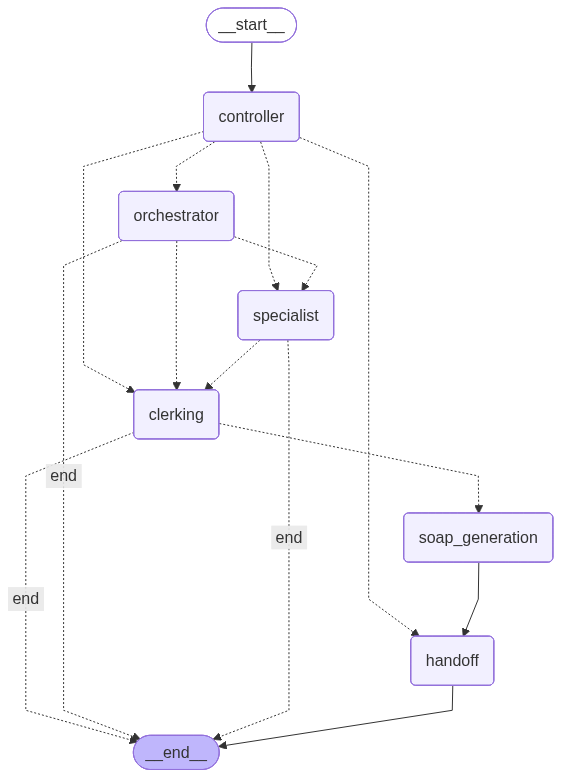

In [2]:
graph